# 1. 引入模块


In [3]:
from typing import List,Dict,Any                    # 导入类型注解：列表、字典、任意类型
from langchain.agents import create_agent           # 导入创建Agent的函数
from langchain.tools import tool                    # 导入工具装饰器
from langchain.chat_models import init_chat_model   # 导入初始化大模型函数

```python
主管Agent（Supervisor）
    ｜- 任务分解
    ｜- 拆解分配------｜
    ｜- 整合结果      |
                    |
                    |
            |-----------------|
        代码助手             研究助手

# 2. 执行智能体-负责执行代码

In [4]:
@tool  
def execute_python_code(code:str)-> str:
    """安全沙箱执行Python代码，返回执行结果

    限制：仅读取exec_globals中名为result的变量作为返回值，无文件/网络操作权限
    
    Args:
        code: 需要执行的Python代码字符串
    
    Returns:
        str: 执行成功返回result变量值，无result返回提示文本，执行失败返回错误信息
    
    Raises:
        无外部异常：所有执行异常均被捕获并转为字符串返回
    """
    safe_globals = {}  # 安全沙箱：空全局命名空间，禁止访问危险内置函数
    exec_globals = {}  # 代码执行命名空间，存储运行时变量

    try:
        # 在隔离环境中执行代码，防止权限泄露
        exec(code,safe_globals,exec_globals)

        if "result" in exec_globals:
            output = str(exec_globals["result"])
        else:
            output = "代码返回成功（无返回值）"

    except Exception as e:
        return f"执行错误：{str(e)}"
    
    return output

In [5]:
model = init_chat_model(
    model="ollama:qwen3.6:latest",
    # 模型温度：值越低输出越稳定确定，值越高越灵活有创意
    temperature=0.5,
    # 本地Ollama服务接口地址
    base_url="http://192.168.8.21:11434"
)

def create_code_agent():
    """创建具备Python代码执行能力的LangChain Agent

    绑定预配置的大模型与代码沙箱执行工具，用于处理代码编写、运行、调试需求
    
    Returns:
        Agent: 配置完成的代码助手Agent实例
    """
    return create_agent(
        model=model,
        tools=[execute_python_code],
        # 定义Agent核心角色与行为规则
        system_prompt="""
你是一个专业的代码助手，擅长编写和执行Python代码。
        
你的职责：
1. 根据用户需求编写Python代码
2. 执行代码并解释结果
3. 调试代码错误

重要提示：
- 使用 execute_python_code 工具执行代码
- 对于复杂问题，先拆解为多个小步骤
- 返回结果时要清晰、易懂
        """
    )

# 3. 搜索智能体-负责网络搜索

In [6]:
@tool                                          # 注册为Agent可调用网络搜索工具
def web_search(query:str,max_results:int=3)->str:
    """离线模拟网络搜索工具，无真实联网请求，仅匹配内置词条库

    Args:
        query: 用户搜索关键词
        max_results: 搜索结果最大返回条数

    Returns:
        str: 匹配到的词条信息，无匹配内容则返回未找到提示
    """
    # 离线Mock搜索知识库，无外部网络请求
    mock_results = {
        "LangChain": "LangChain 是一个用于构建 LLM 应用的开源框架。最新版本 v1.0 专注于 Agent 开发。",
        "Python": "Python 是广泛使用的编程语言，以简洁易读著称。",
        "AI": "人工智能正在快速发展，LLM 是当前热点方向。"
    }

    # 忽略大小写模糊匹配，提升检索容错率
    for key,value in mock_results.items():
        if key.lower() in query.lower():
            return f"搜索结果：\n-{key}:{value}"
    return f"未找到关于{query}的详细信息,建议使用其他更具体的关键词"

In [7]:
def create_search_agent():
    return create_agent(
        model=model,
        tools=[web_search],
        system_prompt="""
        你是一个专业的研究助手，擅长信息搜索和知识整理。
        
你的职责：
1. 搜索用户需要的信息
2. 整合搜索结果，提供总结
3. 引用信息来源

重要提示：
- 使用 web_search 工具获取信息
- 搜索结果可能不完整，如有需要可进行多次搜索
- 用结构化的方式呈现信息
        """
    )

# 4. 主管智能体-负责分发任务

In [8]:
@tool
def delegate_to_code_agent(task:str)->str:
    """
    将任务委派给代码助手 子agent;
    代码助手擅长编写和执行python代码,解决编程问题。

    args:
        task: 需要代码助手处理的任务描述。
    """

    #创建一个智能体
    code_agent = create_code_agent()

    #调用智能体
    result = code_agent.invoke({
        "messages":[{
            "role":"user",
            "content":task
        }]
    })
    return f"[代码助手的回复]\n{result["messages"][-1].content}"


In [9]:
@tool 
def delegate_to_search_agent(task:str) -> str :
    """
    将任务委派给研究子Agent。
    研究助手擅长信息搜索，知识整理和资料汇总

    Args：
        task:需要研究助理处理的任务描述

    """

    # 创建一个研究助手
    search_agent = create_search_agent()

    #执行调用
    result = search_agent.invoke({
        "messages":[{
            "role":"user",
            "content":task
        }]
    })

    return f"[研究助手的回复]\n{result["messages"][-1].content}"


In [10]:
#创建主管agent

def create_supervisor_agent():
    """创建主管Agent, 负责调度子agent。"""
    
    supervisor_prompt = """
你是一个智能任务调度主管。你的职责是将复杂任务拆解并分配给最合适的专家助手。

## 可用的专家助手

1. **代码助手** (通过 delegate_to_code_agent 调用)
   - 擅长：编写代码、执行代码、调试程序、数据计算
   - 示例任务："写一个计算斐波那契数列的函数"

2. **研究助手** (通过 delegate_to_search_agent 调用)
   - 擅长：搜索信息、知识整理、资料汇总
   - 示例任务："介绍一下LangChain的主要功能"

## 任务分配原则

- 编程相关问题 → 委派给代码助手
- 信息查询/研究 → 委派给研究助手
- 复合任务（如"研究并实现"）→ 拆解后依次委派
- 简单问题可以直接回答，无需委派

## 调度流程

1. 分析用户请求，判断需要哪些专家
2. 如需要多个专家，依次调用相应的委派工具
3. 整合各专家的结果，返回完整答案

记住：每个委派工具调用时，要提供清晰、完整的任务描述。
"""

    return create_agent(
        model=model,
        tools=[delegate_to_code_agent,delegate_to_search_agent],
        system_prompt=supervisor_prompt
    )

# 5. 调用

In [11]:
supervisor = create_supervisor_agent()

#指定三个任务
tasks=[{"query":"写一个Python函数来计算列表中所有偶数的和，然后测试一下 [1,2,3,4,5,6]","description":"编程任务"},
      
      {"query":"介绍一下LangChain是什么，以及它的主要用途","description":"信息查询"},

      {"query":"我需要一个数据分析方案。首先查一下Pandas库的主要功能，然后写一个读取CSV文件并计算平均值的示例代码。","description":"复合任务（研究+编程）"}]

for i,task in enumerate(tasks,1):#对循环任务编号，从1开始
      print("="*100)
      print(f"\t第{i:02d}任务：{task['description']}")
      print(f"\t\t用户的问题：{task['query']}")
      print("-"*100)

      try:
            result = supervisor.invoke({"messages":[{"role":"user","content":task["query"]}]})

            print(f"\t\t主管的回答:")
            print(">>>",result["messages"][-1].content,"\n")
      except Exception as e:
            print(f"❌错误：{str(e)}")
      print("="*100)

    


	第01任务：编程任务
		用户的问题：写一个Python函数来计算列表中所有偶数的和，然后测试一下 [1,2,3,4,5,6]
----------------------------------------------------------------------------------------------------


KeyboardInterrupt: 

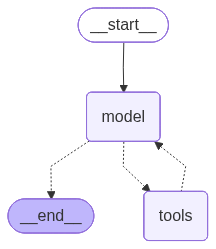

In [12]:
from IPython.display import Image, display
supervisor = create_supervisor_agent()

display(Image(supervisor.get_graph(xray=True).draw_mermaid_png()))